# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
!pip install kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")

print("Path to dataset files:", path)


100%|██████████| 12.6k/12.6k [00:00<00:00, 8.63MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altruistdelhite04/loan-prediction-problem-dataset/versions/1


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
import pandas as pd
import os

file_path = os.path.join(path, "train_u6lujuX_CVtuZ9i.csv")

df = pd.read_csv(file_path)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
df.shape
df.info()
df.columns
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


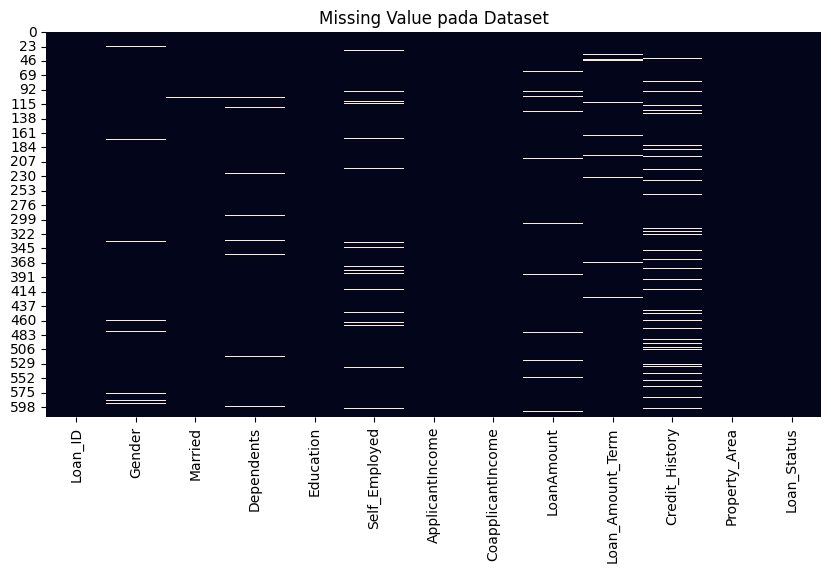

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value pada Dataset")
plt.show()

Cek Duplikat

In [7]:
df.duplicated().sum()

np.int64(0)

Drop Duplikat

In [8]:
df = df.drop_duplicates()

Describe

In [9]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
df.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


Distribusi Target

In [11]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


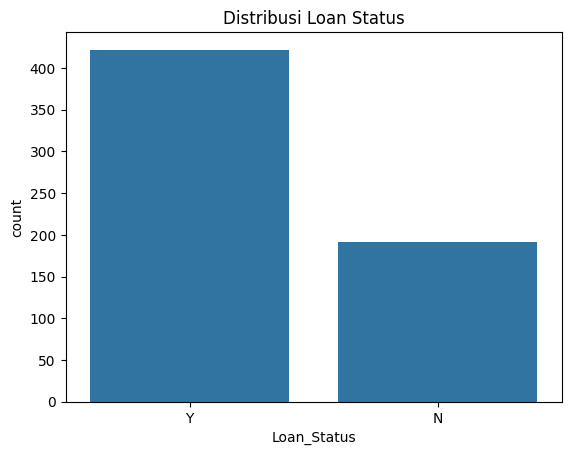

In [12]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Distribusi Loan Status")
plt.show()

EDA Fitur Kategorikal

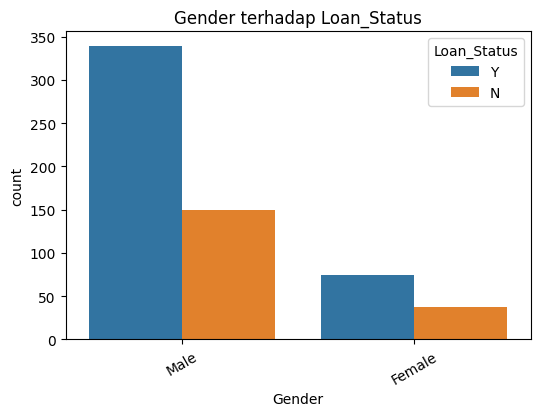

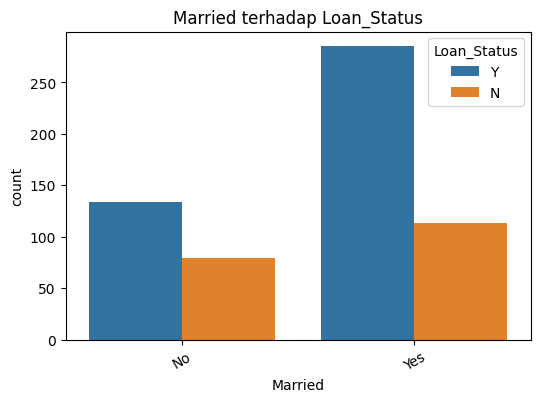

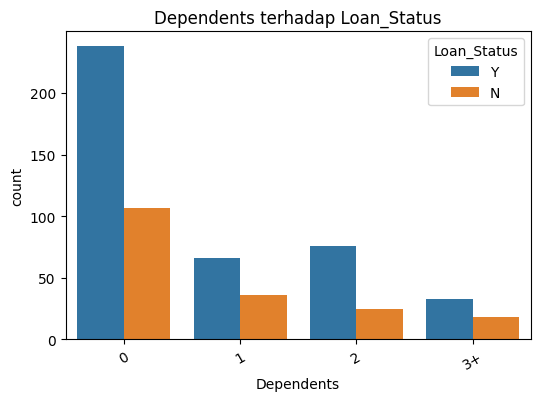

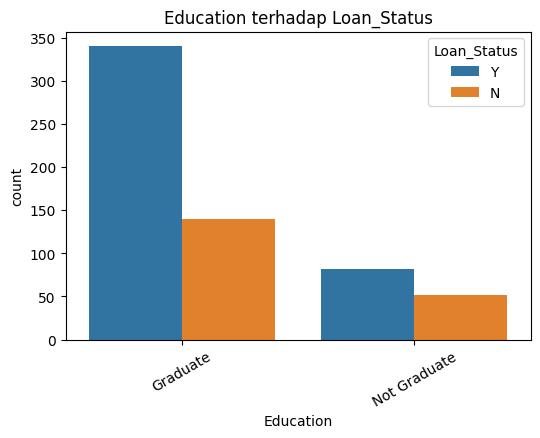

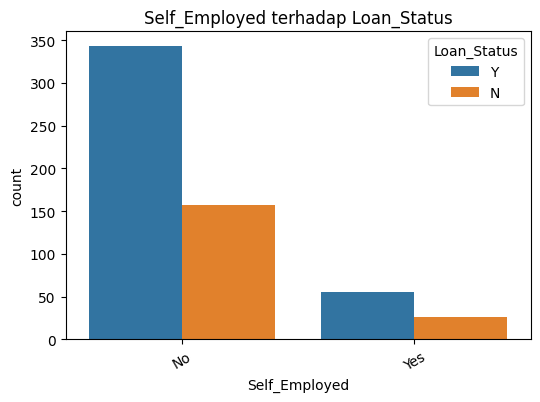

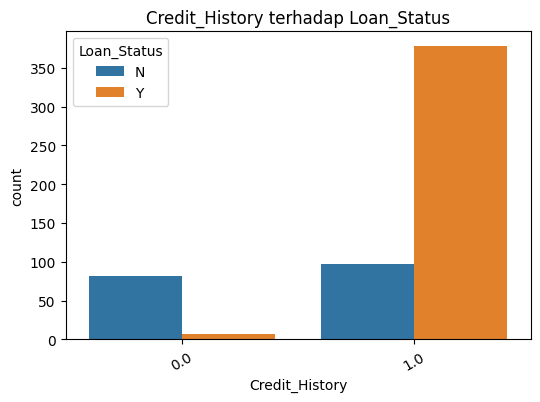

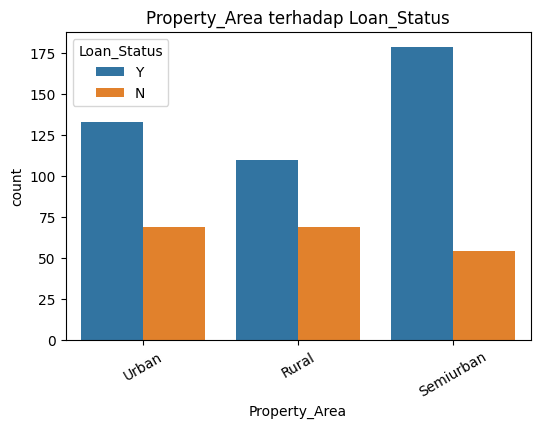

In [13]:
categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area"
]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="Loan_Status", data=df)
    plt.title(f"{col} terhadap Loan_Status")
    plt.xticks(rotation=30)
    plt.show()

EDA Fitur Numerik

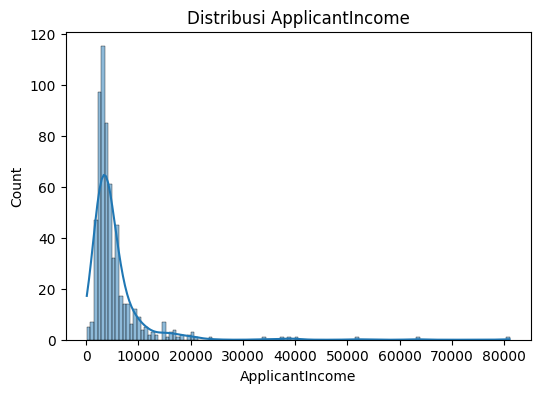

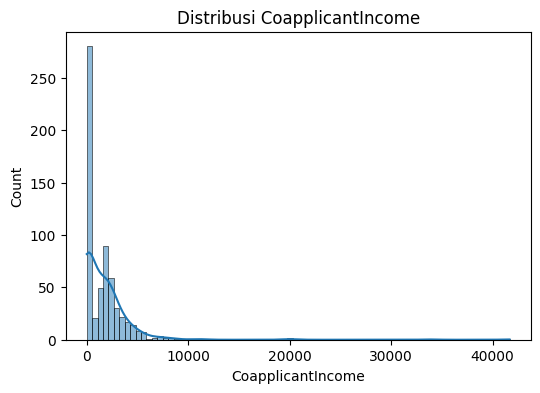

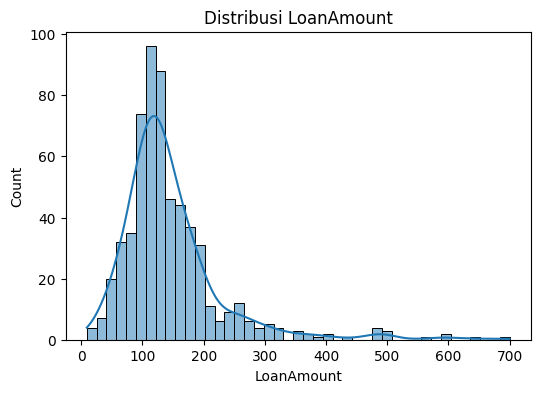

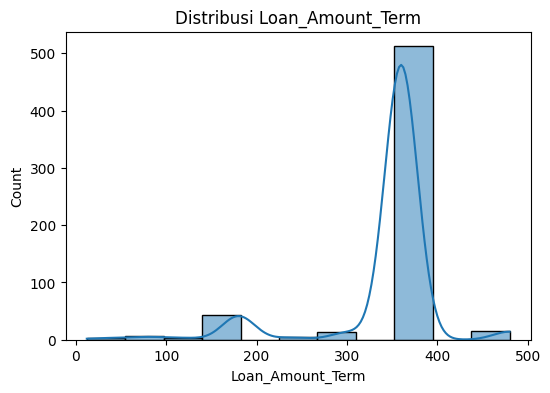

In [14]:
numerical_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.show()

Copy Data untuk Preprocessing

In [15]:
df_clean = df.copy()

Hapus Kolom Loan_ID

In [16]:
df_clean = df_clean.drop(columns=["Loan_ID"])

Isi Missing Value

In [17]:
df_clean["Gender"] = df_clean["Gender"].fillna(df_clean["Gender"].mode()[0])
df_clean["Married"] = df_clean["Married"].fillna(df_clean["Married"].mode()[0])
df_clean["Dependents"] = df_clean["Dependents"].fillna(df_clean["Dependents"].mode()[0])
df_clean["Self_Employed"] = df_clean["Self_Employed"].fillna(df_clean["Self_Employed"].mode()[0])
df_clean["Credit_History"] = df_clean["Credit_History"].fillna(df_clean["Credit_History"].mode()[0])

df_clean["LoanAmount"] = df_clean["LoanAmount"].fillna(df_clean["LoanAmount"].median())
df_clean["Loan_Amount_Term"] = df_clean["Loan_Amount_Term"].fillna(df_clean["Loan_Amount_Term"].median())

cek missing values

In [18]:
df_clean.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


Ubah Dependents 3+ jadi 3

In [19]:
df_clean["Dependents"] = df_clean["Dependents"].replace("3+", "3")

Encoding Data Kategorikal

In [20]:
from sklearn.preprocessing import LabelEncoder

label_cols = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

encoder = LabelEncoder()

for col in label_cols:
    df_clean[col] = encoder.fit_transform(df_clean[col])

Ubah dependents ke integer

In [21]:
df_clean["Dependents"] = df_clean["Dependents"].astype(int)

Pisahkan Fitur dan Target

In [22]:
X = df_clean.drop(columns=["Loan_Status"])
y = df_clean["Loan_Status"]

Scaling Fitur Numerik

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = X.copy()

scale_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

X_scaled[scale_cols] = scaler.fit_transform(X_scaled[scale_cols])

Gabungkan Dataset Final

In [24]:
df_preprocessed = X_scaled.copy()
df_preprocessed["Loan_Status"] = y

df_preprocessed.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,0.072991,-0.554487,-0.211241,0.273231,1.0,2,1
1,1,1,1,0,0,-0.134412,-0.038732,-0.211241,0.273231,1.0,0,0
2,1,1,0,0,1,-0.393747,-0.554487,-0.948996,0.273231,1.0,2,1
3,1,1,0,1,0,-0.462062,0.251980,-0.306435,0.273231,1.0,2,1
4,1,0,0,0,0,0.097728,-0.554487,-0.056551,0.273231,1.0,2,1


simpan dataset preprocessing

In [25]:
df_preprocessed.to_csv("dataset_preprocessing.csv", index=False)

download


In [26]:
from google.colab import files

files.download("dataset_preprocessing.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

membuat file automate .py

In [27]:
%%writefile automate_Azka.py

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

def preprocess(input_path, output_path):
    df = pd.read_csv(input_path)

    df = df.drop_duplicates()

    if "Loan_ID" in df.columns:
        df = df.drop(columns=["Loan_ID"])

    df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
    df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
    df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
    df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
    df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

    df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
    df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

    df["Dependents"] = df["Dependents"].replace("3+", "3")
    df["Dependents"] = df["Dependents"].astype(int)

    label_cols = [
        "Gender",
        "Married",
        "Education",
        "Self_Employed",
        "Property_Area",
        "Loan_Status"
    ]

    encoder = LabelEncoder()

    for col in label_cols:
        df[col] = encoder.fit_transform(df[col])

    X = df.drop(columns=["Loan_Status"])
    y = df["Loan_Status"]

    scale_cols = [
        "ApplicantIncome",
        "CoapplicantIncome",
        "LoanAmount",
        "Loan_Amount_Term"
    ]

    scaler = StandardScaler()
    X[scale_cols] = scaler.fit_transform(X[scale_cols])

    df_preprocessed = X.copy()
    df_preprocessed["Loan_Status"] = y

    df_preprocessed.to_csv(output_path, index=False)

if __name__ == "__main__":
    preprocess("train_u6lujuX_CVtuZ9i.csv", "dataset_preprocessing.csv")

Writing automate_Azka.py


Test automate

In [28]:
import shutil

shutil.copy(file_path, "train_u6lujuX_CVtuZ9i.csv")

'train_u6lujuX_CVtuZ9i.csv'

In [29]:
!python automate_Azka.py

In [30]:
pd.read_csv("dataset_preprocessing.csv").head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,0.072991,-0.554487,-0.211241,0.273231,1.0,2,1
1,1,1,1,0,0,-0.134412,-0.038732,-0.211241,0.273231,1.0,0,0
2,1,1,0,0,1,-0.393747,-0.554487,-0.948996,0.273231,1.0,2,1
3,1,1,0,1,0,-0.462062,0.251980,-0.306435,0.273231,1.0,2,1
4,1,0,0,0,0,0.097728,-0.554487,-0.056551,0.273231,1.0,2,1


In [31]:
files.download("automate_Azka.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>